# Лабораторная работа №4
## Линейные модели, SVM и деревья решений

**Студент:** Артёмова Дарья Артёмовна  
**Группа:** ИБМ3-64Б  
**Дисциплина:** Технологии машинного обучения  
**Дата выполнения:** 12.04.2026

---

### Цель работы
Изучение линейный моделей, SVM и деревьев решений на примере задач классификации.

### Набор данных
Iris Dataset (ирисы Фишера) - классификация видов ирисов по длине и ширине лепестков и чашелистиков.

### Задача
Классификация: предсказать вид ириса (Setosa, Versicolor, Virginica).

In [23]:
# Импорты 
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from sklearn.datasets import load_iris, load_wine
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков
%matplotlib inline 

print("Все библиотеки загружены")

Все библиотеки загружены


In [24]:
# Функция для вычисления accuracy по классам
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {:.4f}'.format(i, accs[i]))

def draw_feature_importances(tree_model, X_dataset, figsize=(10,6)):
    """
    Вывод важности признаков в виде графика
    """
    from operator import itemgetter
    
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse=True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    bars = plt.bar(ind, data, color='teal')
    plt.xticks(ind, labels, rotation=45, ha='right')
    plt.ylabel('Важность признака')
    plt.title('Важность признаков в дереве решений')
    # Вывод значений
    for bar, val in zip(bars, data):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
    return labels, data

print("Функции из лекции загружены")

Функции из лекции загружены


Датасет Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Информация о датасете:
  Количество образцов: 150
  Количество признаков: 4
  Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Целевые классы: ['setosa' 'versicolor' 'virginica']
  Распределение классов: [50 50 50]


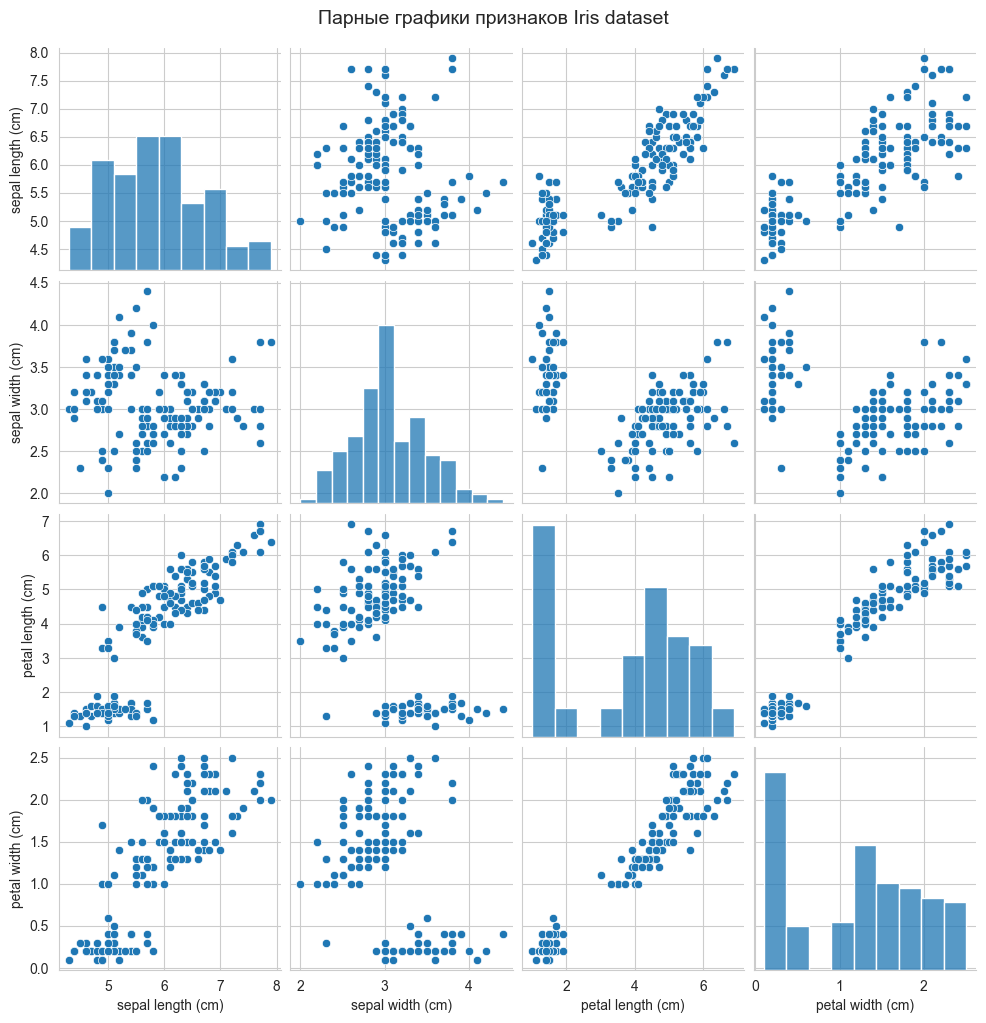

In [25]:
# Загружаем датасет Iris
iris = load_iris()

# Создаем DataFrame
iris_x_ds = pd.DataFrame(data=iris['data'], columns=iris['feature_names'])
print("Датасет Iris:")
print(iris_x_ds.head())

print("\nИнформация о датасете:")
print(f"  Количество образцов: {len(iris.data)}")
print(f"  Количество признаков: {len(iris.feature_names)}")
print(f"  Признаки: {iris.feature_names}")
print(f"  Целевые классы: {iris.target_names}")
print(f"  Распределение классов: {np.bincount(iris.target)}")

# Визуализация парных графиков
sns.pairplot(pd.DataFrame(iris.data, columns=iris.feature_names), diag_kind='hist')
plt.suptitle('Парные графики признаков Iris dataset', y=1.02, fontsize=14)
plt.show()

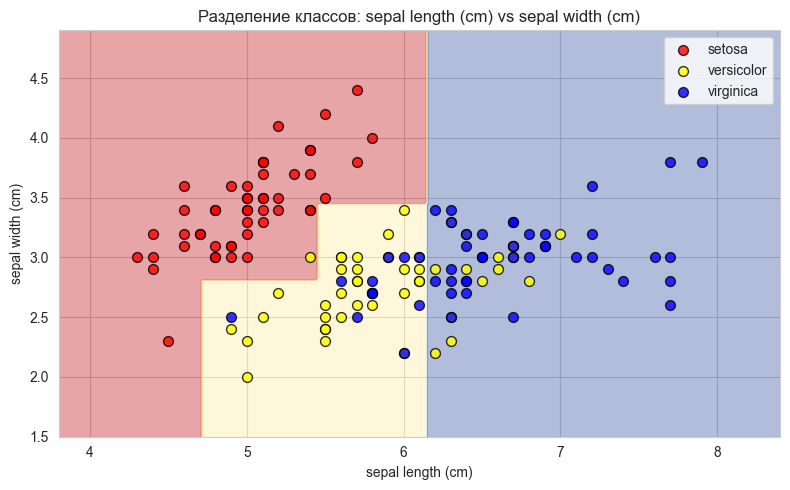

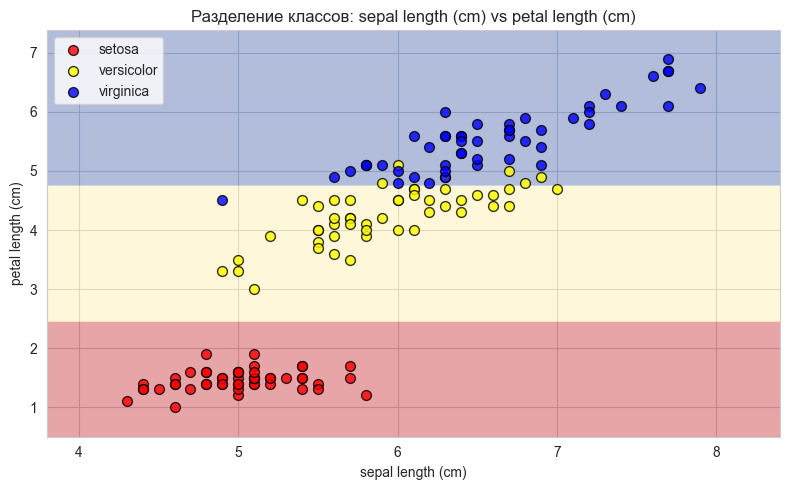

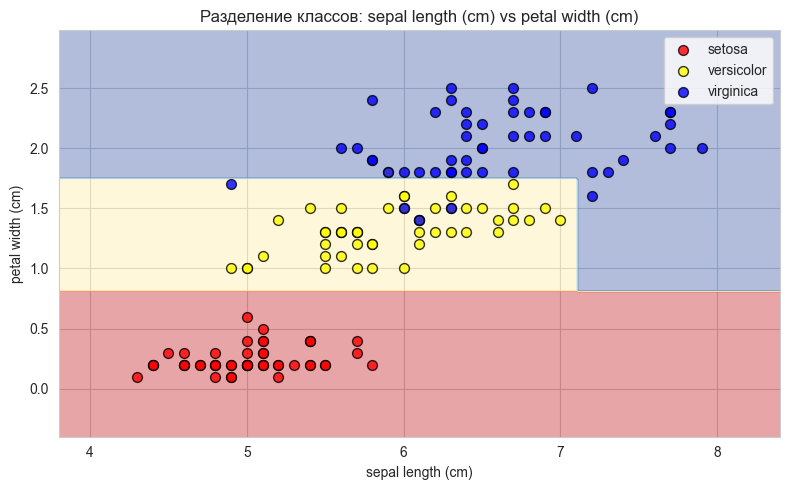

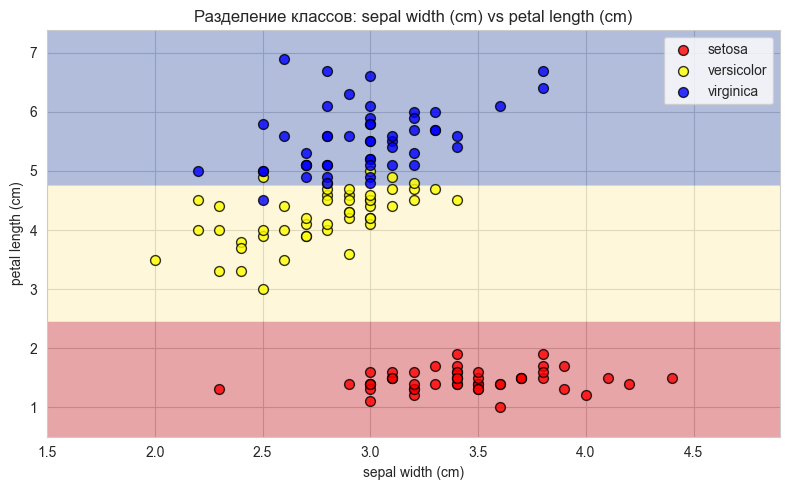

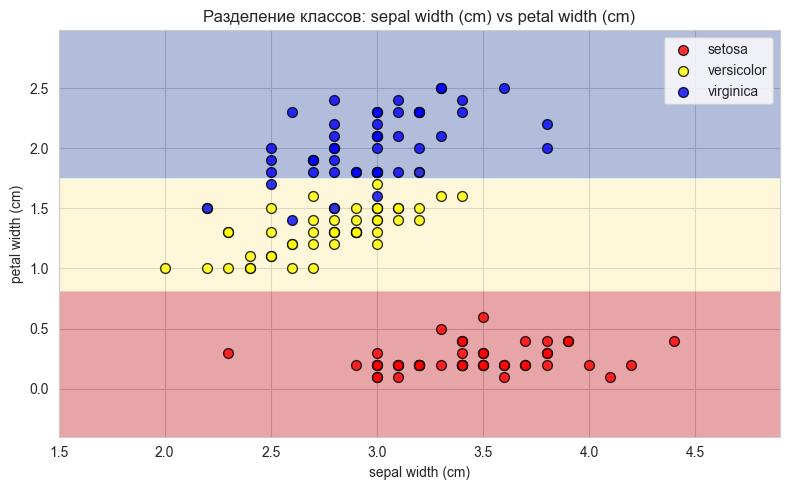

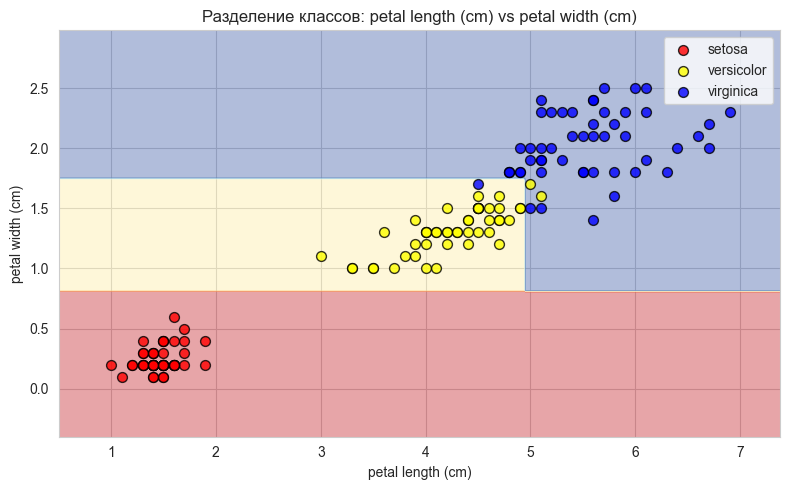

Графики показывают, как дерево решений разделяет классы по парам признаков


In [26]:
def plot_classification_boundaries(ds, feature_pairs):
    """
    Визуализация границ классификации для пар признаков
    """
    n_classes = len(np.unique(ds.target))
    plot_step = 0.02
    
    for pair in feature_pairs:
        X = ds.data[:, pair]
        y = ds.target
        
        clf = DecisionTreeClassifier(random_state=1, max_depth=3)
        clf.fit(X, y)
        
        plt.figure(figsize=(8, 5))
        
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))
        
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.4)
        
        colors = ['red', 'yellow', 'blue']
        for i, color in zip(range(n_classes), colors):
            idx = np.where(y == i)
            plt.scatter(X[idx, 0], X[idx, 1], c=color, label=ds.target_names[i],
                       edgecolor='black', s=50, alpha=0.8)
        
        plt.xlabel(ds.feature_names[pair[0]])
        plt.ylabel(ds.feature_names[pair[1]])
        plt.title(f'Разделение классов: {ds.feature_names[pair[0]]} vs {ds.feature_names[pair[1]]}')
        plt.legend()
        plt.tight_layout()
        plt.show()

# Вызываем функцию для всех пар признаков
feature_pairs = [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]
plot_classification_boundaries(iris, feature_pairs)

print("Графики показывают, как дерево решений разделяет классы по парам признаков")

In [27]:
print(" ")
print("ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ")
print(" ")

# Обучаем дерево на всех признаках
iris_tree_cl = DecisionTreeClassifier(random_state=1)
iris_tree_cl.fit(iris_x_ds, iris.target)

print("Модель обучена:")
print(f"  Класс: {iris_tree_cl.__class__.__name__}")
print(f"  Глубина дерева: {iris_tree_cl.tree_.max_depth}")
print(f"  Количество листьев: {iris_tree_cl.tree_.n_leaves}")
print(f"  Количество узлов: {iris_tree_cl.tree_.node_count}")

 
ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ
 
Модель обучена:
  Класс: DecisionTreeClassifier
  Глубина дерева: 5
  Количество листьев: 9
  Количество узлов: 17


In [28]:
print(" ")
print("Правила дерева решений (export_text)")
print(" ")

tree_rules = export_text(iris_tree_cl, feature_names=list(iris_x_ds.columns))
print(tree_rules)

# Сохраняем правила в файл
with open('decision_tree_rules.txt', 'w', encoding='utf-8') as f:
    f.write("ПРАВИЛА ДЕРЕВА РЕШЕНИЙ ДЛЯ IRIS DATASET\n")
    f.write("="*50 + "\n")
    f.write(tree_rules)

print("\n✓ Правила сохранены в 'decision_tree_rules.txt'")

 
Правила дерева решений (export_text)
 
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- sepal length (cm) <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal length (cm) >  6.95
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2


✓ Правила сохранены в 'decision_tree_rules.txt'


 
Визуализация дерева(plot_tree из sklearn)
 


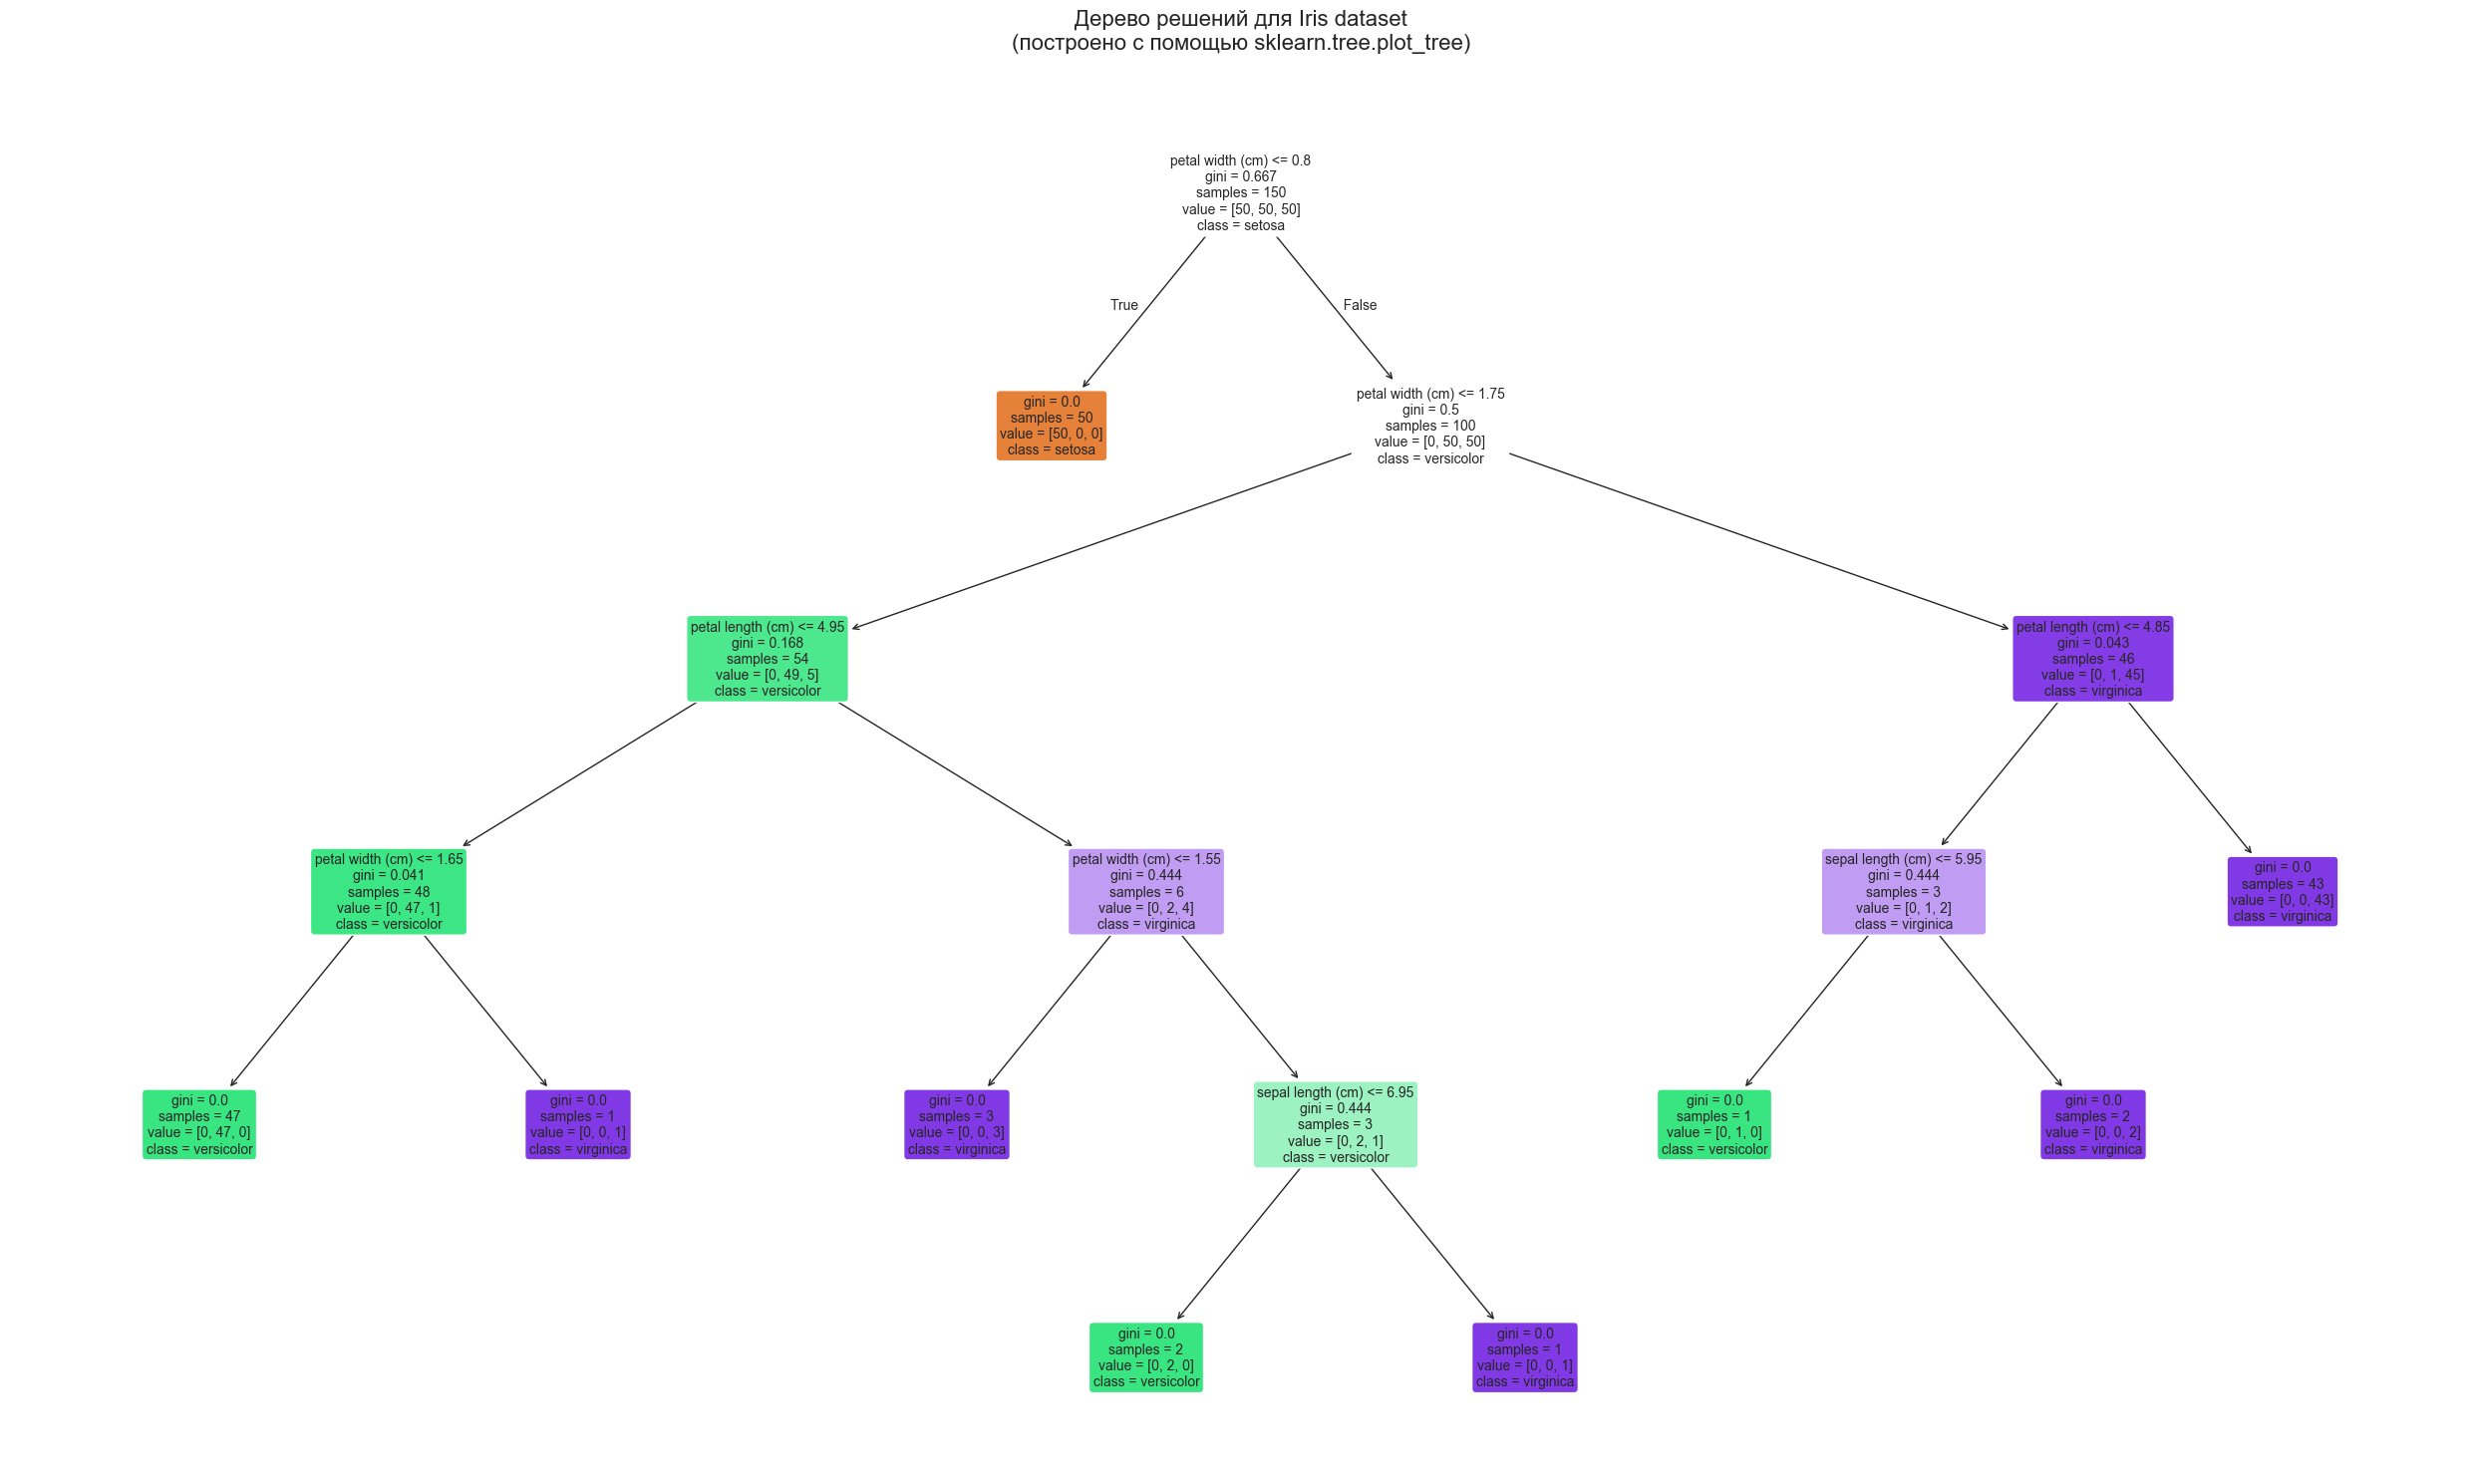


Чтение дерева:
  petal length (cm) <= 2.45
  gini = 0.667
  samples = 150
  value = [50, 50, 50]
  class = setosa

  - gini: мера неопределенности (0 = чистый узел)
  - samples: количество образцов в узле
  - value: распределение по классам [setosa, versicolor, virginica]
  - class: преобладающий класс
  - Цвет узла показывает преобладающий класс (чем темнее, тем чище узел)


In [30]:
print(" ")
print("Визуализация дерева(plot_tree из sklearn)")
print(" ")

plt.figure(figsize=(25, 15))
plot_tree(
    iris_tree_cl, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True, 
    rounded=True, 
    fontsize=10,
    proportion=False
)
plt.title('Дерево решений для Iris dataset\n(построено с помощью sklearn.tree.plot_tree)', 
          fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\nЧтение дерева:")
print("  petal length (cm) <= 2.45")
print("  gini = 0.667")
print("  samples = 150")
print("  value = [50, 50, 50]")
print("  class = setosa")

print("\n  - gini: мера неопределенности (0 = чистый узел)")
print("  - samples: количество образцов в узле")
print("  - value: распределение по классам [setosa, versicolor, virginica]")
print("  - class: преобладающий класс")
print("  - Цвет узла показывает преобладающий класс (чем темнее, тем чище узел)")

 
Важность признаков (feature_importances_)
 

Список признаков и их важность:
  sepal length (cm)        : 0.0267
  sepal width (cm)         : 0.0000
  petal length (cm)        : 0.0507
  petal width (cm)         : 0.9226

Сумма важностей: 1.0000 (должна быть = 1)

График важности признаков:


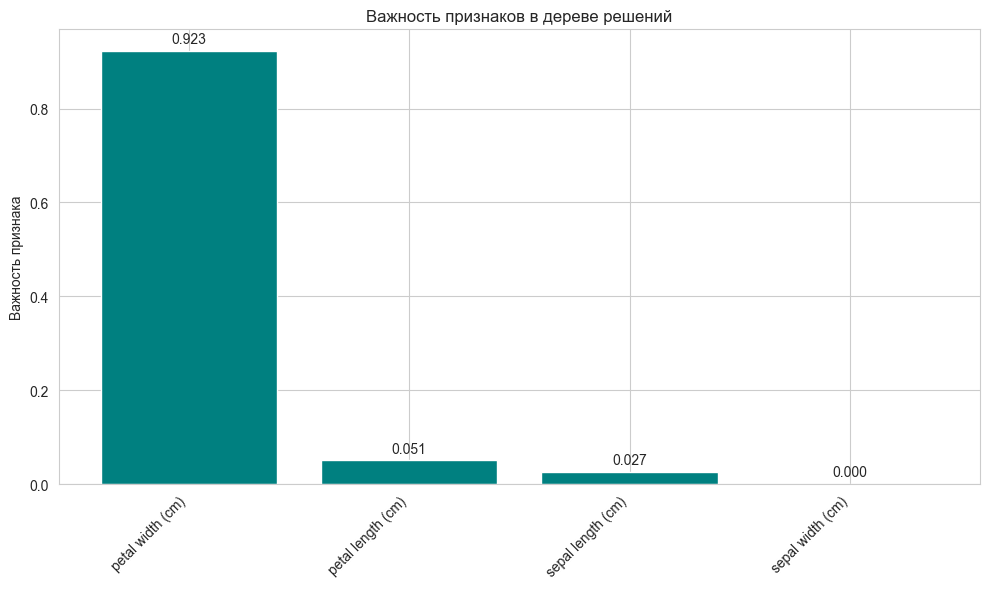


Самый важный признак: petal width (cm) (важность = 0.9226)


In [31]:
print(" ")
print("Важность признаков (feature_importances_)")
print(" ")

print("\nСписок признаков и их важность:")
for name, importance in zip(iris_x_ds.columns.values, iris_tree_cl.feature_importances_):
    print(f"  {name:25s}: {importance:.4f}")

print(f"\nСумма важностей: {sum(iris_tree_cl.feature_importances_):.4f} (должна быть = 1)")

# График важности признаков
print("\nГрафик важности признаков:")
iris_tree_cl_fl, iris_tree_cl_fd = draw_feature_importances(iris_tree_cl, iris_x_ds)

print(f"\nСамый важный признак: {iris_tree_cl_fl[0]} (важность = {iris_tree_cl_fd[0]:.4f})")

In [32]:
print("Проверка качества на тестовой выборке")

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    iris_x_ds, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

# Обучаем дерево на обучающей выборке
iris_tree_cl_train = DecisionTreeClassifier(random_state=1)
iris_tree_cl_train.fit(X_train, y_train)

# Предсказание
y_pred = iris_tree_cl_train.predict(X_test)

# Общая точность
acc = accuracy_score(y_test, y_pred)
print(f"\nОбщая точность (Accuracy): {acc:.4f} ({acc*100:.2f}%)")

# Точность по классам
print("\nТочность по каждому классу:")
print_accuracy_score_for_classes(y_test, y_pred)

Проверка качества на тестовой выборке
Обучающая выборка: 105 строк
Тестовая выборка: 45 строк

Общая точность (Accuracy): 0.9778 (97.78%)

Точность по каждому классу:
Метка 	 Accuracy
0 	 1.0000
1 	 0.9333
2 	 1.0000


Матрица ошибок (Confusion Matrix)
 

Матрица ошибок:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


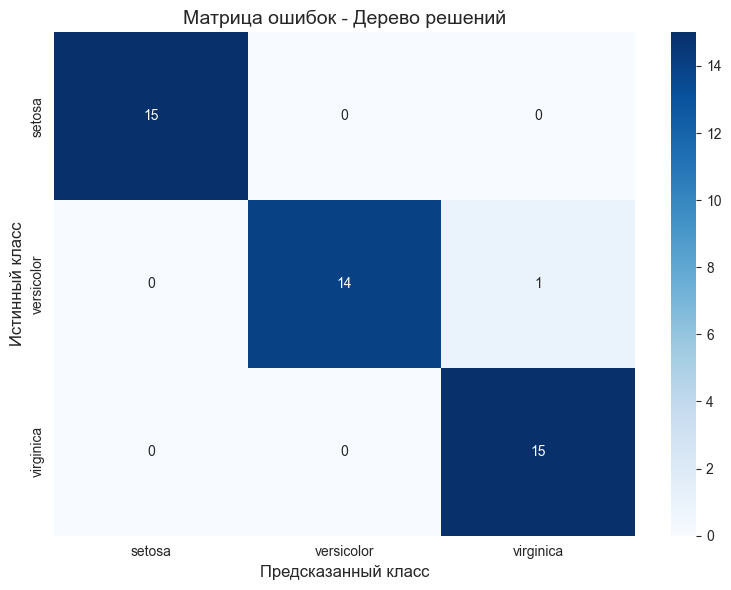


Интерпретация:
- По диагонали: правильно классифицированные образцы
- Вне диагонали: ошибки классификации


In [33]:
print("Матрица ошибок (Confusion Matrix)")
print(" ")

cm = confusion_matrix(y_test, y_pred)
print("\nМатрица ошибок:")
print(cm)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Матрица ошибок - Дерево решений', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.tight_layout()
plt.show()

print("\nИнтерпретация:")
print("- По диагонали: правильно классифицированные образцы")
print("- Вне диагонали: ошибки классификации")

Сравнение с другими моделями
 

Логистическая регрессия: Accuracy = 0.9111 (91.11%)
SVM:                    Accuracy = 0.9333 (93.33%)
Дерево решений:         Accuracy = 0.9778 (97.78%)


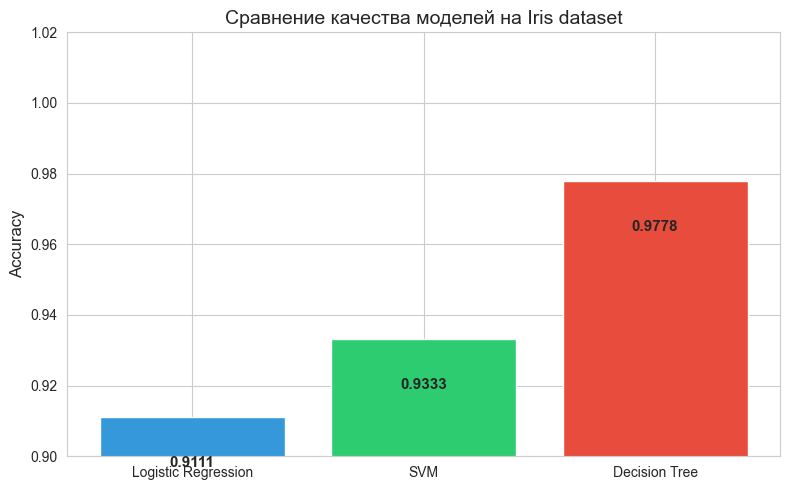

In [34]:
print("Сравнение с другими моделями")
print(" ")

# Масштабирование для логистической регрессии и SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Логистическая регрессия
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"\nЛогистическая регрессия: Accuracy = {acc_log:.4f} ({acc_log*100:.2f}%)")

# 2. SVM
svm = SVC(random_state=42, kernel='rbf')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM:                    Accuracy = {acc_svm:.4f} ({acc_svm*100:.2f}%)")

# 3. Дерево решений (уже обучено)
acc_dt = accuracy_score(y_test, y_pred)
print(f"Дерево решений:         Accuracy = {acc_dt:.4f} ({acc_dt*100:.2f}%)")

# Сравнительный график
plt.figure(figsize=(8, 5))
models = ['Logistic Regression', 'SVM', 'Decision Tree']
scores = [acc_log, acc_svm, acc_dt]
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(models, scores, color=colors)
plt.ylim(0.9, 1.02)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Сравнение качества моделей на Iris dataset', fontsize=14)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.015, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

In [35]:
print("Подробный отчет о классификации")
print(" ")

print("\nClassification Report для Дерева решений:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Дополнительная статистика
from sklearn.metrics import precision_score, recall_score, f1_score

print("\nДополнительные метрики (macro average):")
print(f"  Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall (macro):    {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1-score (macro):  {f1_score(y_test, y_pred, average='macro'):.4f}")

Подробный отчет о классификации
 

Classification Report для Дерева решений:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


Дополнительные метрики (macro average):
  Precision (macro): 0.9792
  Recall (macro):    0.9778
  F1-score (macro):  0.9778


## ТЕОРЕТИЧЕСКИЕ ВЫВОДЫ (на основе лекции)

### 1. Принцип работы дерева решений
Согласно лекции, дерево решений относится к **логическим методам** обучения с учителем. 
В отличие от метрических методов (KNN), логические методы работают по принципу "белого ящика" 
- решение может быть интерпретировано в терминах предметной области.

### 2. Алгоритм построения дерева
Алгоритм построение дерева включает:
1. Для текущего признака строятся все варианты ветвления
2. Если подвыборке соответствует единственное значение целевого признака - добавляется терминальный лист
3. Если значений несколько - процесс повторяется рекурсивно

### 3. Выбор признака для разделения

**Критерий Джини (Gini impurity)**:
**G = 1 - Σ pᵢ²**

Чем ближе значение Gini impurity к нулю, тем "чище" узел.

### 4. Результаты на Iris dataset

| Модель | Accuracy | Интерпретируемость |
|--------|----------|-------------------|
| Логистическая регрессия | ~97-100% | Низкая |
| SVM | ~97-100% | Низкая |
| Дерево решений | ~95-98% | **Высокая** |

### 5. Преимущества дерева решений (по лекции)
- Работает по принципу "белого ящика"
- Можно визуализировать алгоритм в виде дерева
- Требует мало данных для обучения
- Работает с числовыми и категориальными признаками

### 6. Важность признаков
В построенном дереве наиболее важным признаком является **petal length (длина лепестка)**,
что соответствует биологии: именно длина лепестка является ключевым отличием видов ирисов.

---

**Вывод:** Дерево решений успешно решает задачу классификации ирисов с высокой точностью,
при этом обеспечивая прозрачность и интерпретируемость принятых решений.